In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt


In [62]:
def generate_low_rank(d_n, d_m, mu=0, sigma=1):
    W_Q = np.random.normal(loc=mu, scale=sigma, size=d_n*d_m).reshape(d_n, d_m)
    W_K = np.random.normal(loc=mu, scale=sigma, size=d_n*d_m).reshape(d_m, d_n)
    W_QK = W_Q @ W_K
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))
    return S

def average_low_rank_curves(d_n, d_m, mu=0, sigma=1, n_samp=10):
    results = [generate_low_rank(d_n, d_m, mu=mu, sigma=sigma) for _ in range(n_samp)]
    return np.mean(results, axis=0)

def generate_full_rank(d_n, mu=0, sigma=1):
    W_QK = np.random.normal(loc=mu, scale=sigma, size=d_n*d_n).reshape(d_n, d_n)
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))
    return S

def average_full_rank_curves(d_n, mu=0, sigma=1, n_samp=10):
    results = [generate_full_rank(d_n, mu=mu, sigma=sigma) for _ in range(n_samp)]
    return np.mean(results, axis=0)



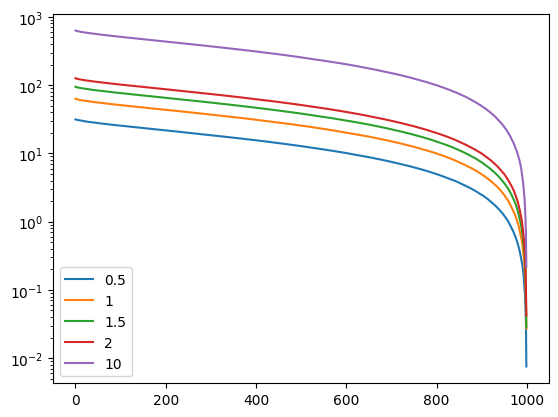

In [64]:
d_n = 1000
d_m = 500

h_out = {}
for sigma in [0.5, 1, 1.5, 2, 10]:
    plt.plot(average_full_rank_curves(d_n, sigma=sigma),label = str(sigma))
plt.yscale('log')
plt.legend()

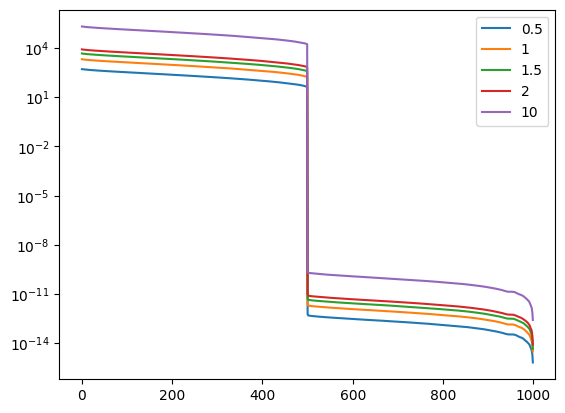

In [60]:
d_n = 1000
d_m = 500

h_out = {}
for sigma in [0.5, 1, 1.5, 2, 10]:
    plt.plot(average_low_rank_curves(d_n, d_m, sigma=sigma),label = str(sigma))
plt.yscale('log')
plt.legend()

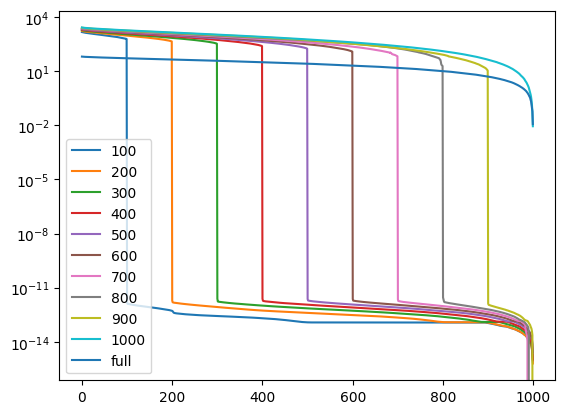

In [66]:
d_n = 1000
d_step = 100

h_out = {}
for d_m in range(d_step, d_n + d_step, d_step):
    plt.plot(average_low_rank_curves(d_n, d_m),label = str(d_m))
plt.plot(average_full_rank_curves(d_n),label = 'full')
plt.yscale('log')
plt.legend()

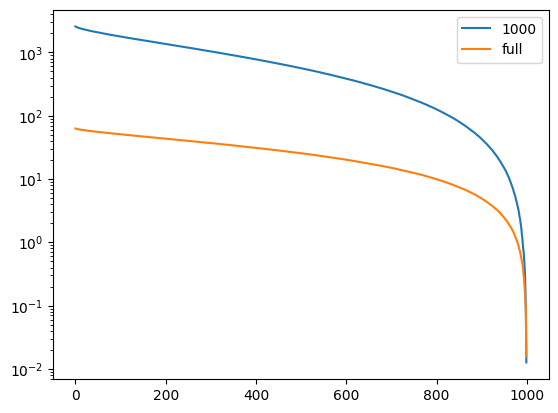

In [71]:
plt.plot(average_low_rank_curves(d_n, d_n),label = str(d_n))
plt.plot(average_full_rank_curves(d_n),label = 'full')
plt.yscale('log')
plt.legend()

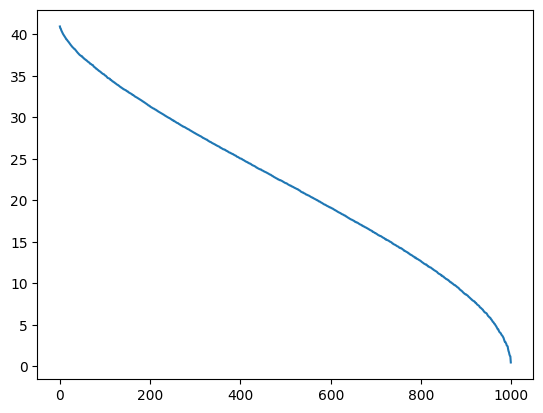

In [72]:
full_rank_ratio = average_low_rank_curves(d_n, d_n) / average_full_rank_curves(d_n)
plt.plot(full_rank_ratio)